## 1. Setup & Imports

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from pathlib import Path

import implicit
import lightfm
import faiss
import hnswlib
import torch

print("Everything works!")

/Users/aleksandrzelenskij/Desktop/github/advanced-recommender-systems/.venv/lib/python3.9/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


Everything works!


In [4]:
DATA_DIR = Path("../data/raw")

category_tree_path = DATA_DIR / "category_tree.csv"
events_path = DATA_DIR / "events.csv"
item_properties_p1_path = DATA_DIR / "item_properties_part1.csv"
item_properties_p2_path = DATA_DIR / "item_properties_part2.csv"

In [5]:
category_tree = pd.read_csv(category_tree_path)
events = pd.read_csv(events_path)
item_properties_p1 = pd.read_csv(item_properties_p1_path)
item_properties_p2 = pd.read_csv(item_properties_p2_path)

## 2. Exploratory Data Analysis

### 2.1 Dataset Overview

In [6]:
print("Category tree:", category_tree.shape)
print("Events:", events.shape)
print("Item properties part1:", item_properties_p1.shape)
print("Item properties part2:", item_properties_p2.shape)

Category tree: (1669, 2)
Events: (2756101, 5)
Item properties part1: (10999999, 4)
Item properties part2: (9275903, 4)


In [7]:
category_tree.head()

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [8]:
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [9]:
item_properties_p1.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [10]:
item_properties_p2.head()

,timestamp,itemid,property,value
0,1433041200000,183478,561,769062
1,1439694000000,132256,976,n26.400 1135780
2,1435460400000,420307,921,1149317 1257525
3,1431831600000,403324,917,1204143
4,1435460400000,230701,521,769062


### Dataset Overview

The RetailRocket dataset consists of four complementary files.

- **events.csv** contains user interactions with products and serves as the primary source for building recommendation models.
- **category_tree.csv** describes the hierarchical structure of product categories.
- **item_properties_part1.csv** and **item_properties_part2.csv** contain historical metadata describing product attributes over time.

The **events** table will be the main dataset used throughout this project, while the remaining files provide additional contextual information that can later be incorporated into content-based and hybrid recommendation models.

### 2.2 Dataset Description

In [11]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


In [12]:
events.describe(include="all")

,timestamp,visitorid,event,itemid,transactionid
count,2.756101e+06,2.756101e+06,2756101,2.756101e+06,22457.000000
unique,NaN,NaN,3,NaN,NaN
top,NaN,NaN,view,NaN,NaN
freq,NaN,NaN,2664312,NaN,NaN
mean,1.436424e+12,7.019229e+05,NaN,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,NaN,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,NaN,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,NaN,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,NaN,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,NaN,3.507150e+05,13224.000000


In [13]:
events.isna().sum()

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

In [14]:
category_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


In [18]:
category_tree.isna().sum()

categoryid     0
parentid      25
dtype: int64

In [15]:
item_properties_p1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999999 entries, 0 to 10999998
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 335.7+ MB


In [19]:
item_properties_p1.isna().sum()

timestamp    0
itemid       0
property     0
value        0
dtype: int64

In [16]:
item_properties_p2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9275903 entries, 0 to 9275902
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 283.1+ MB


In [20]:
item_properties_p2.isna().sum()

timestamp    0
itemid       0
property     0
value        0
dtype: int64

In [21]:
events["datetime"] = pd.to_datetime(
    events["timestamp"],
    unit="ms"
)

item_properties_p1["datetime"] = pd.to_datetime(
    item_properties_p1["timestamp"],
    unit="ms"
)

item_properties_p2["datetime"] = pd.to_datetime(
    item_properties_p2["timestamp"],
    unit="ms"
)

In [22]:
print(events["datetime"].min())
print(events["datetime"].max())

print(item_properties_p1["datetime"].min())
print(item_properties_p1["datetime"].max())

print(item_properties_p2["datetime"].min())
print(item_properties_p2["datetime"].max())

2015-05-03 03:00:04.384000
2015-09-18 02:59:47.788000
2015-05-10 03:00:00
2015-09-13 03:00:00
2015-05-10 03:00:00
2015-09-13 03:00:00


### Timestamp Conversion

The original timestamps are stored as Unix timestamps in milliseconds.

For better interpretability, they are converted into human-readable datetime format.

Observation period:

- User interactions: **2015-05-03 — 2015-09-18**
- Item properties: **2015-05-10 — 2015-09-13**

The recommendation models in this project will rely on the interaction timestamps to preserve the chronological order of user behavior.

### 2.3 Event Distribution

In [23]:
events["event"].value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

In [24]:
events["event"].value_counts(normalize=True) * 100

event
view           96.669607
addtocart       2.515583
transaction     0.814810
Name: proportion, dtype: float64

### 2.4 User Statistics

#### 2.4.1 Number of unique users

In [25]:
n_users = events["visitorid"].nunique()

print(f"Unique users: {n_users:,}")

Unique users: 1,407,580


#### 2.4.2 Number of interactions per user

In [26]:
user_interactions = (
    events.groupby("visitorid")
          .size()
          .rename("interactions")
)

user_interactions.describe()

count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
Name: interactions, dtype: float64

### 2.4.3 Top active users

In [27]:
user_interactions.sort_values(ascending=False).head(10)

visitorid
1150086    7757
530559     4328
152963     3024
895999     2474
163561     2410
371606     2345
286616     2252
684514     2246
892013     2024
861299     1991
Name: interactions, dtype: int64

### 2.4.4 Distribution of user activity

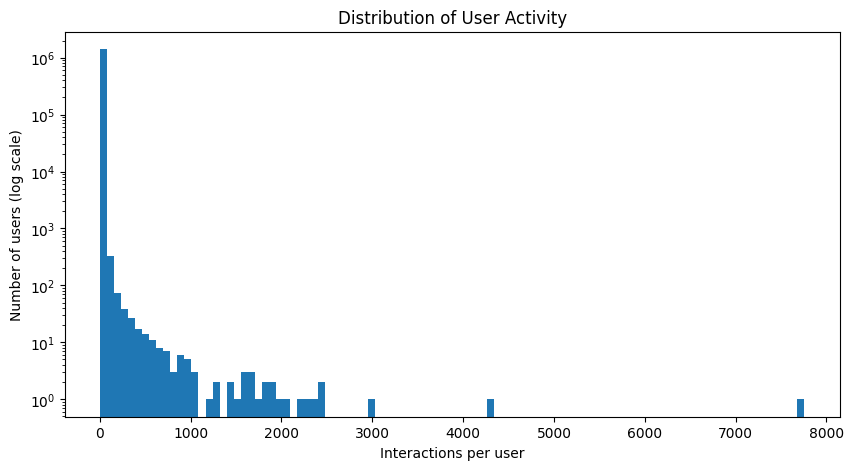

In [28]:
plt.figure(figsize=(10,5))

plt.hist(
    user_interactions,
    bins=100,
    log=True
)

plt.xlabel("Interactions per user")
plt.ylabel("Number of users (log scale)")
plt.title("Distribution of User Activity")

plt.show()

In [29]:
user_interactions.quantile(
    [
        0.5,
        0.75,
        0.9,
        0.95,
        0.99
    ]
)

0.50     1.0
0.75     2.0
0.90     3.0
0.95     5.0
0.99    13.0
Name: interactions, dtype: float64

### User Statistics

The dataset contains **1,407,580 unique users** and exhibits a highly skewed interaction distribution.

Key observations:

- The average user performs **approximately 2 interactions**, while the median user has only **1 interaction**.
- **75%** of users interact with **no more than 2 items**.
- **95%** of users have **5 or fewer interactions**.
- Even the **99th percentile** contains only **13 interactions**.
- A very small number of extremely active users generate thousands of interactions (up to **7,757**), forming a long-tail distribution.

This level of sparsity is typical for implicit feedback recommendation datasets. Most users provide very limited interaction history, making personalized recommendation challenging and motivating the use of collaborative filtering and representation learning methods.

### 2.5 Item Statistics

#### 2.5.1 Number of unique items

In [30]:
n_items = events["itemid"].nunique()

print(f"Unique items: {n_items:,}")

Unique items: 235,061


#### 2.5.2 Number of interactions per item

In [31]:
item_interactions = (
    events.groupby("itemid")
          .size()
          .rename("interactions")
)

item_interactions.describe()

count    235061.000000
mean         11.725046
std          37.032101
min           1.000000
25%           1.000000
50%           3.000000
75%           9.000000
max        3412.000000
Name: interactions, dtype: float64

#### 2.5.3 Most popular items

In [32]:
item_interactions.sort_values(ascending=False).head(10)

itemid
187946    3412
461686    2978
5411      2334
370653    1854
219512    1800
257040    1647
298009    1642
96924     1633
309778    1628
384302    1608
Name: interactions, dtype: int64

#### 2.5.4 Distribution of item popularity

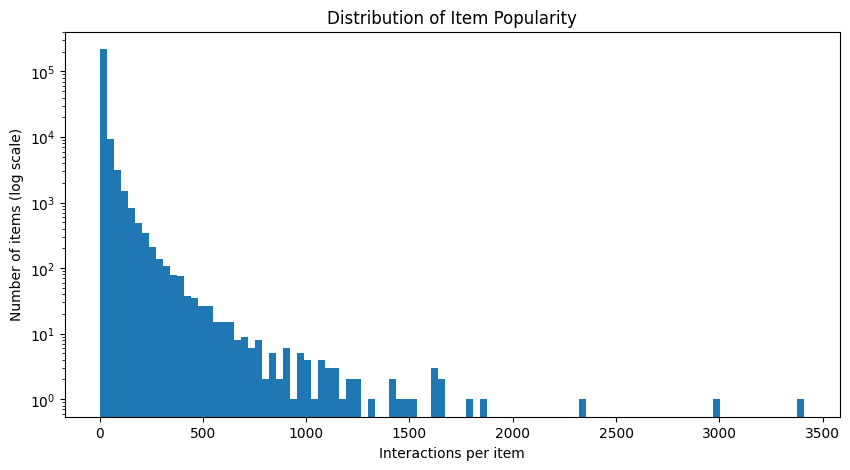

In [33]:
plt.figure(figsize=(10,5))

plt.hist(
    item_interactions,
    bins=100,
    log=True
)

plt.xlabel("Interactions per item")
plt.ylabel("Number of items (log scale)")
plt.title("Distribution of Item Popularity")

plt.show()

#### 2.5.5 Percentiles

In [34]:
item_interactions.quantile(
    [
        0.5,
        0.75,
        0.9,
        0.95,
        0.99
    ]
)

0.50      3.0
0.75      9.0
0.90     25.0
0.95     47.0
0.99    143.0
Name: interactions, dtype: float64

### Item Statistics

The dataset contains **235,061 unique items**.

Key observations:

- The average item receives **approximately 12 interactions**, while the median item receives only **3 interactions**.
- **75%** of items have **9 or fewer interactions**.
- **95%** of items have **47 or fewer interactions**.
- Even the **99th percentile** contains only **143 interactions**.
- The most popular item appears in **3,412 interactions**, indicating a small number of highly popular products.

The item popularity distribution also follows a long-tail pattern. While a handful of products accumulate thousands of interactions, the vast majority receive only a few visits. This popularity imbalance is a common characteristic of real-world e-commerce recommendation datasets.

### 2.6 Temporal Analysis

#### 2.6.1 Interactions over time

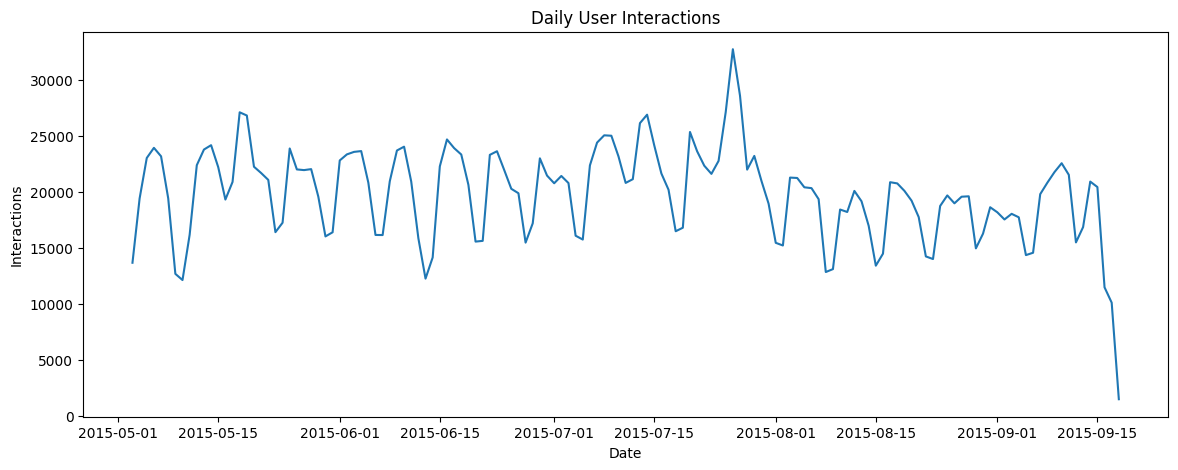

In [35]:
daily_events = (
    events
    .set_index("datetime")
    .resample("D")
    .size()
)

plt.figure(figsize=(14,5))
plt.plot(daily_events)

plt.title("Daily User Interactions")
plt.xlabel("Date")
plt.ylabel("Interactions")

plt.show()

#### 2.6.2 Interactions by weekday

<Axes: xlabel='weekday'>

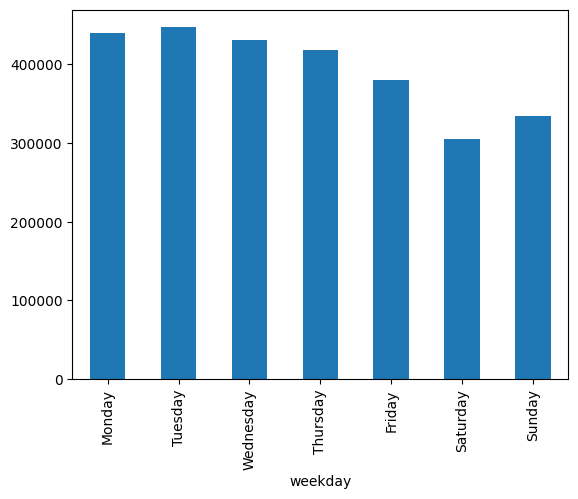

In [36]:
events["weekday"] = events["datetime"].dt.day_name()

events["weekday"].value_counts().reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]).plot(kind="bar")

#### 2.6.3 Interactions by hour

<Axes: xlabel='hour'>

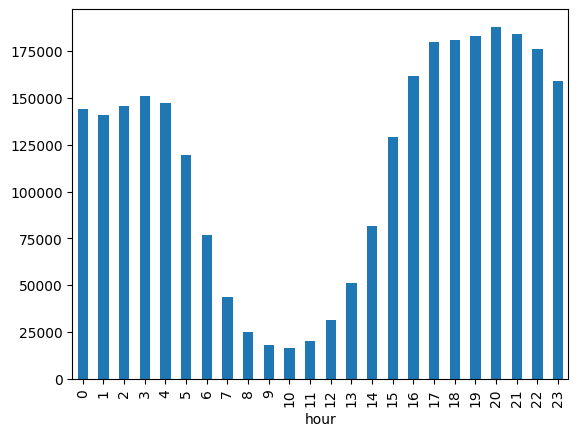

In [37]:
events["hour"] = events["datetime"].dt.hour

events["hour"].value_counts().sort_index().plot(kind="bar")

#### 2.6.4 Event types over time

<Axes: xlabel='datetime'>

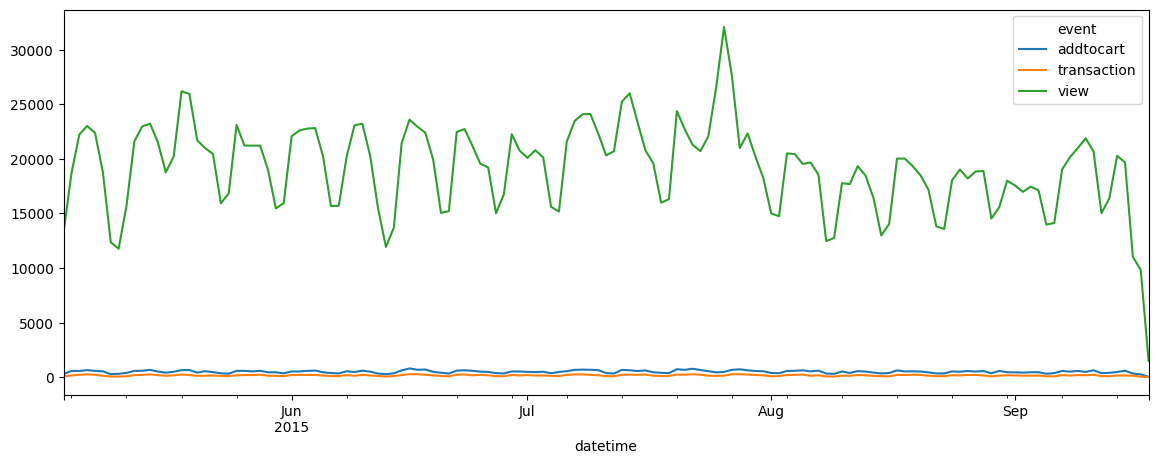

In [38]:
daily_by_event = (
    events
    .groupby([
        pd.Grouper(key="datetime", freq="D"),
        "event"
    ])
    .size()
    .unstack(fill_value=0)
)

daily_by_event.plot(figsize=(14,5))

### Temporal Analysis

Several temporal patterns can be observed from the interaction logs:

- User activity follows a clear weekly cycle, with lower traffic during weekends.
- Most interactions occur in the late afternoon and evening, peaking between **17:00 and 21:00**.
- User activity is relatively stable throughout the observation period, although a noticeable spike appears in late July.
- The final days of the dataset contain significantly fewer interactions because the dataset ends in the middle of the day. These records should not be interpreted as a real drop in user activity.
- All event types (views, add-to-cart actions, and transactions) follow similar temporal dynamics, suggesting consistent user behavior throughout the collection period.

### 2.7 Interaction Matrix Analysis

In [40]:
n_users = events["visitorid"].nunique()
n_items = events["itemid"].nunique()
n_interactions = len(events)

density = n_interactions / (n_users * n_items)

print(f"Users: {n_users:,}")
print(f"Items: {n_items:,}")
print(f"Interactions: {n_interactions:,}")
print(f"Matrix density: {density * 100:.6f}%")
print(f"Sparsity: {(1-density)*100:.6f}%")

Users: 1,407,580
Items: 235,061
Interactions: 2,756,101
Matrix density: 0.000833%
Sparsity: 99.999167%


### Interaction Matrix Analysis

The interaction matrix contains:

- **1,407,580 users**
- **235,061 items**
- **2,756,101 interactions**

The resulting user-item matrix has a density of only **0.000833%**, meaning that over **99.999%** of all possible user-item pairs contain no interactions.

Such extreme sparsity is a defining characteristic of real-world recommendation systems. Traditional machine learning methods are generally ineffective in this setting, making collaborative filtering and matrix factorization techniques particularly well suited for this problem.

The high sparsity observed in the RetailRocket dataset motivates the use of implicit-feedback recommendation algorithms, beginning with **Implicit ALS**, which will be implemented in the next notebook.

## Key Findings

The exploratory analysis revealed several important characteristics of the RetailRocket dataset:

- The dataset contains **2.76 million interactions** generated by **1.41 million users** across **235 thousand products**.
- User behavior is highly sparse: the median user performs only **one interaction**, while **99% of users have no more than 13 interactions**.
- Product popularity follows a clear long-tail distribution, with most items receiving only a few interactions and a small number of highly popular products.
- User activity exhibits both daily and weekly temporal patterns, with higher engagement during evenings and weekdays.
- The user-item interaction matrix is extremely sparse (**99.999% sparse**), making collaborative filtering methods particularly suitable.

Overall, the RetailRocket dataset closely resembles real-world industrial recommendation datasets and provides an excellent benchmark for evaluating implicit-feedback recommendation algorithms.